In [28]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In this step, the required Python libraries are imported.
Pandas is used for handling and analyzing the dataset, matplotlib is used for visualization, and sklearn is used for building and evaluating the machine learning model.

In [33]:
data = pd.read_csv("student-mat.csv", sep=';')

In this step, the dataset is loaded from a CSV file into a DataFrame named data.
This dataset contains various academic and personal attributes of students.

In [31]:
print(data.head())

  school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0  GP;"F";18;"U";"GT3";"A";4;4;"at_home";"teacher...                                                                                                                                                                                 
1  GP;"F";17;"U";"GT3";"T";1;1;"at_home";"other";...                                                                                                                                                                                 
2  GP;"F";15;"U";"LE3";"T";1;1;"at_home";"other";...                                                                                                                                                                                 
3  GP;"F";15;"U";"GT3";"T";4;2;"health";"services...                            

This step displays the first five rows of the dataset.
It helps in understanding the structure, columns, and type of data present in the dataset.

In [34]:
def classify_performance(marks):
    if marks >= 15:
        return "High"
    elif marks >= 10:
        return "Average"
    else:
        return "Low"

data['performance'] = data['G3'].apply(classify_performance)

In this step, a new column called performance is created based on the final grade (G3).
The marks are categorized into three groups:

High (≥15)
Average (10–14)
Low (<10)

This transformation converts the problem into a classification task.

In [35]:
X = data[['G1', 'G2', 'studytime', 'failures', 'absences']]
y = data['performance']

Here, the input features (independent variables) and the target variable (dependent variable) are defined.
The model will use these features to predict the performance category.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is divided into training and testing sets.
80% of the data is used to train the model, and 20% is used to test it.
This ensures that the model is evaluated on unseen data.

In [37]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In this step, a Decision Tree Classifier is created and trained using the training data.
The model learns patterns and relationships between input features and the target variable.

In [38]:
y_pred = model.predict(X_test)

The trained model is used to make predictions on the test dataset.
These predicted values will be compared with actual values to evaluate performance.

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8607594936708861
              precision    recall  f1-score   support

     Average       0.80      0.88      0.84        32
        High       1.00      0.85      0.92        20
         Low       0.85      0.85      0.85        27

    accuracy                           0.86        79
   macro avg       0.88      0.86      0.87        79
weighted avg       0.87      0.86      0.86        79



This step evaluates the model using accuracy and classification metrics.
Accuracy shows the percentage of correct predictions, while the classification report provides detailed performance measures such as precision, recall, and F1-score.

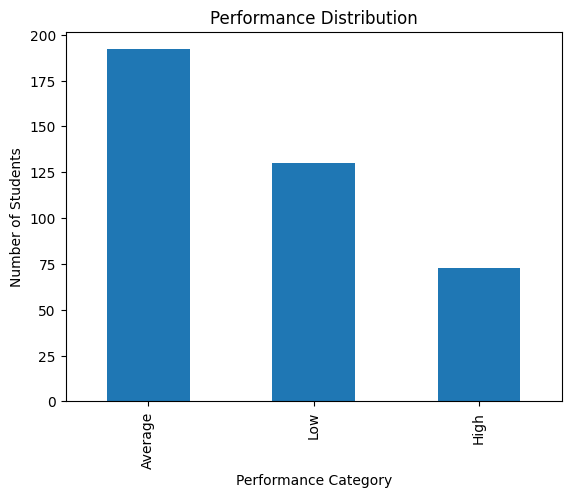

In [40]:
data['performance'].value_counts().plot(kind='bar')
plt.title("Performance Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.show()

A bar chart is created to visualize the distribution of students across different performance categories.
This helps in understanding how many students fall into each category.